# Capítulo 4: Series de Tiempo. Caso de Estudio 1: Clima

> Dora María Ballesteros  
> Primera edición, 2026  
> ISBN: 978-1-957395-63-0  
> 🔗 **[Consultar el libro en Editorial REDIPE](https://editorial.redipe.org/index.php/1/catalog/book/245)**

**Versión:** Septiembre de 2026

---

## Material complementario del libro

Este notebook acompaña el **Capítulo 4** del libro *Investigación en Ciencia de Datos* y continúa el desarrollo del **Caso de Estudio 1: Clima**.

En el notebook anterior se realizó el **Análisis Exploratorio de Datos (EDA) aplicado a Series de Tiempo**, estudiando la evolución temporal de las variables, la dependencia entre diferentes series y la relación entre valores actuales y pasados.

En este notebook utilizaremos el **dataset resultante de ese proceso de EDA** para continuar con **Feature Engineering (FE)**. A partir de los resultados obtenidos en los experimentos anteriores, seleccionaremos los mejores *features* generados mediante **Rolling** y **Lags**, y los integraremos con los *features* temporales **hora** y **día de la semana** para entrenar un nuevo modelo.

# **1. Lectura y previsualización del dataset**

In [ ]:
import pandas as pd
clima_df = pd.read_csv("/content/clima_eda.csv")
clima_df.head()

,tiempo_hora_local,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima_num
0,2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,4
1,2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,4
2,2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,4
3,2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,4
4,2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,4


**CONVERTIR LA COLUMNDA DE TIEMPO A ÍNDICE**

In [ ]:
clima_df["tiempo_hora_local"] = pd.to_datetime(clima_df["tiempo_hora_local"])
clima_df = clima_df.set_index("tiempo_hora_local")

In [ ]:
clima_df.head()

,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima_num
tiempo_hora_local,,,,,,,,,,,
2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,4
2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,4
2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,4
2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,4
2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,4


# **2.  Feature Engineering**

### 🔎 Selección de features

A partir de los resultados obtenidos en los experimentos anteriores, vamos a seleccionar los **mejores features generados mediante Rolling y Lags**, junto con los *features* temporales **hora** y **día de la semana**.

Los *features* seleccionados son:

**Rolling**
- `temperatura_rolling_12`
- `humedad_rolling_12`
- `punto_rocio_rolling_48`
- `punto_rocio_rolling_24`
- `punto_rocio_rolling_12`

**Lags**
- `indice_UV_lag_12`
- `indice_UV_lag_48`
- `punto_rocio_lag_12`
- `punto_rocio_lag_24`
- `presion_lag_72`

**Features temporales**
- `hora`
- `dia_semana`

En total, utilizaremos **12 features seleccionados** para entrenar un nuevo modelo y analizar su desempeño.

**2.1. ROLLING**

In [ ]:
# Rolling seleccionados
clima_df["temperatura_rolling_12"] = (
    clima_df["temperatura"]
    .shift(1)
    .rolling(window=12)
    .mean()
)

clima_df["humedad_rolling_12"] = (
    clima_df["humedad"]
    .shift(1)
    .rolling(window=12)
    .mean()
)

clima_df["punto_rocio_rolling_48"] = (
    clima_df["punto_rocio"]
    .shift(1)
    .rolling(window=48)
    .mean()
)

clima_df["punto_rocio_rolling_24"] = (
    clima_df["punto_rocio"]
    .shift(1)
    .rolling(window=24)
    .mean()
)

clima_df["punto_rocio_rolling_12"] = (
    clima_df["punto_rocio"]
    .shift(1)
    .rolling(window=12)
    .mean()
)

**2.2. LAGS**

In [ ]:
# Lags seleccionados
clima_df["indice_UV_lag_12"] = clima_df["indice_UV"].shift(12)
clima_df["indice_UV_lag_48"] = clima_df["indice_UV"].shift(48)

clima_df["punto_rocio_lag_12"] = clima_df["punto_rocio"].shift(12)
clima_df["punto_rocio_lag_24"] = clima_df["punto_rocio"].shift(24)

clima_df["presion_lag_72"] = clima_df["presion"].shift(72)

**2.3. FEATURES TEMPORALES**

In [ ]:
# Features temporales
clima_df["hora"] = clima_df.index.hour
clima_df["dia_semana"] = clima_df.index.dayofweek + 1

In [ ]:
clima_df.head(20)

,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,...,punto_rocio_rolling_48,punto_rocio_rolling_24,punto_rocio_rolling_12,indice_UV_lag_12,indice_UV_lag_48,punto_rocio_lag_12,punto_rocio_lag_24,presion_lag_72,hora,dia_semana
tiempo_hora_local,,,,,,,,,,,,,,,,,,,,,
2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2
2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2
2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2
2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2
2019-10-01 05:00:00,23.0,1.0,21.56,94.0,2.09,4.47,1008.03,0.0,271.6,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,2
2019-10-01 06:00:00,24.0,1.0,21.97,95.0,2.31,4.07,1008.61,0.0,271.8,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,2
2019-10-01 07:00:00,25.0,1.0,22.34,96.0,2.98,4.65,1008.97,0.0,272.4,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,2
2019-10-01 08:00:00,25.0,1.0,22.35,99.0,3.44,5.14,1009.53,1.0,272.8,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,2


In [ ]:
features_seleccionados = [
    "hora",
    "dia_semana",
    "temperatura_rolling_12",
    "humedad_rolling_12",
    "punto_rocio_rolling_48",
    "punto_rocio_rolling_24",
    "punto_rocio_rolling_12",
    "indice_UV_lag_12",
    "indice_UV_lag_48",
    "punto_rocio_lag_12",
    "punto_rocio_lag_24",
    "presion_lag_72"
]

# **3.  MODELAMIENTO SÓLO CON LOS FEATURES NUEVOS**

### 🔎 Modelamiento con los nuevos features

En este primer experimento utilizaremos únicamente los **12 features seleccionados** mediante los experimentos anteriores de Feature Engineering.

Después de eliminar los valores faltantes generados por Rolling y Lags, el dataset se divide temporalmente utilizando el **70 % de las observaciones para entrenamiento y el 30 % para prueba**, conservando el orden cronológico de los datos.

In [ ]:
modelo_df = clima_df[features_seleccionados + ["estado_clima_num"]].dropna()

In [ ]:
# Variables de entrada y salida
X = modelo_df[features_seleccionados]
y = modelo_df["estado_clima_num"]

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)


Dimensión de X: (427, 12)
Dimensión de y: (427,)


In [ ]:
# Punto de corte: 70 % entrenamiento - 30 % prueba
punto_corte = int(len(modelo_df) * 0.7)

# División temporal
X_train = X.iloc[:punto_corte]
X_test  = X.iloc[punto_corte:]

y_train = y.iloc[:punto_corte]
y_test  = y.iloc[punto_corte:]

print("Observaciones de entrenamiento:", len(X_train))
print("Observaciones de prueba:", len(X_test))

print("\nPeriodo de entrenamiento:")
print(X_train.index.min(), "a", X_train.index.max())

print("\nPeriodo de prueba:")
print(X_test.index.min(), "a", X_test.index.max())

Observaciones de entrenamiento: 298
Observaciones de prueba: 129

Periodo de entrenamiento:
2019-10-04 00:00:00 a 2019-10-16 09:00:00

Periodo de prueba:
2019-10-16 10:00:00 a 2019-10-21 18:00:00


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Modelo FE - Rolling
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenamiento
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predicciones
y_pred = modelo.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print()

# Reporte por clase
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Accuracy: 0.7907

              precision    recall  f1-score   support

           1       0.95      0.98      0.97        60
           2       0.64      1.00      0.78        43
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        23

    accuracy                           0.79       129
   macro avg       0.40      0.50      0.44       129
weighted avg       0.66      0.79      0.71       129



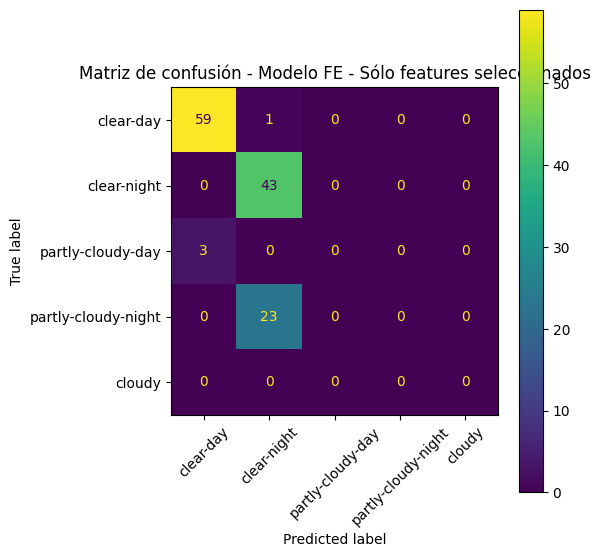

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[1, 2, 3, 4, 5]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'clear-day',
        'clear-night',
        'partly-cloudy-day',
        'partly-cloudy-night',
        'cloudy'
    ]
)

disp.plot(ax=ax, xticks_rotation=45)

plt.title('Matriz de confusión - Modelo FE - Sólo features seleccionados')
plt.tight_layout()
plt.show()

### 🧠 Analiza

Aunque el modelo alcanza un **accuracy de 0.7907**, observa la matriz de confusión y el número de muestras disponibles para cada clase.

- ¿Todas las clases se encuentran igualmente representadas en el conjunto de prueba?
- ¿Cómo puede afectar esta distribución al desempeño observado para las clases con menor número de muestras?
- Teniendo en cuenta este resultado, ¿es suficiente analizar únicamente el *accuracy* para evaluar el desempeño del modelo?

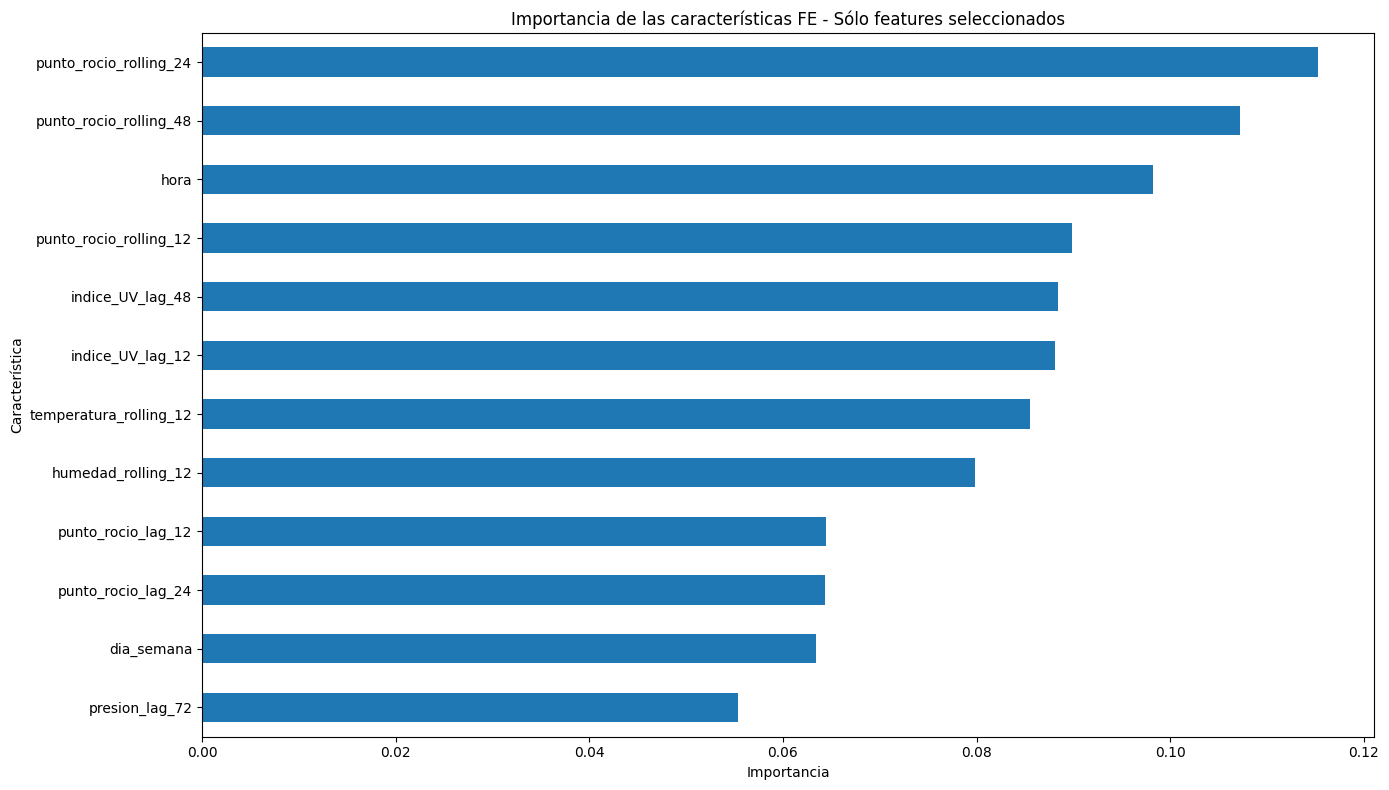

In [ ]:
# Importancia de las características

import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    modelo.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(14, 8))
importancias.plot(kind="barh")

plt.xlabel("Importancia")
plt.ylabel("Característica")
plt.title("Importancia de las características FE - Sólo features seleccionados")

plt.tight_layout()
plt.show()

### 🔎 Análisis de los features seleccionados

Al entrenar el modelo únicamente con los **12 features seleccionados**, observamos que las características generadas mediante **Rolling, Lags y variables temporales** presentan diferentes niveles de importancia.

Los *features* asociados al **punto de rocío** ocupan varias de las primeras posiciones, especialmente los generados mediante Rolling. También se destaca **hora** como uno de los *features* más relevantes del modelo.

> 💡 Observa que la importancia obtenida por un *feature* puede cambiar al modificar el conjunto de características utilizadas para entrenar el modelo.

# **4.  MODELAMIENTO FEATURES NUEVOS (12) CON LOS FEATURES ORIGINALES (10)**

### 🔎 Combinación con los features originales

En el siguiente experimento combinaremos los **12 nuevos features seleccionados** con los **10 features originales**, obteniendo un conjunto de **22 características**.

El objetivo es analizar si incorporar nuevamente la información original permite mejorar el desempeño obtenido utilizando únicamente los nuevos features.

In [ ]:
features_originales = [
    "temperatura",
    "humedad",
    "presion",
    "velocidad_viento",
    "direccion_viento",
    "intensidad_precipitacion",
    "indice_UV",
    "punto_rocio",
    "rafagas_viento",
    "ozono"
]

In [ ]:
features_combinados = features_originales + features_seleccionados

In [ ]:
modelo_combinado_df = clima_df[
    features_combinados + ["estado_clima_num"]
].dropna()

In [ ]:
print("Número de features:", len(features_combinados))
print("Features únicos:", len(set(features_combinados)))

Número de features: 22
Features únicos: 22


In [ ]:
# Variables de entrada y salida
X = modelo_combinado_df.drop(columns=["estado_clima_num"])
y = modelo_combinado_df["estado_clima_num"]

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (427, 22)
Dimensión de y: (427,)


In [ ]:
# Punto de corte: 70 % entrenamiento - 70 % prueba
punto_corte = int(len(modelo_combinado_df) * 0.7)

# División temporal
X_train = X.iloc[:punto_corte]
X_test  = X.iloc[punto_corte:]

y_train = y.iloc[:punto_corte]
y_test  = y.iloc[punto_corte:]

print("Observaciones de entrenamiento:", len(X_train))
print("Observaciones de prueba:", len(X_test))

print("\nPeriodo de entrenamiento:")
print(X_train.index.min(), "a", X_train.index.max())

print("\nPeriodo de prueba:")
print(X_test.index.min(), "a", X_test.index.max())

Observaciones de entrenamiento: 298
Observaciones de prueba: 129

Periodo de entrenamiento:
2019-10-04 00:00:00 a 2019-10-16 09:00:00

Periodo de prueba:
2019-10-16 10:00:00 a 2019-10-21 18:00:00


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Modelo FE - Rolling
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenamiento
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predicciones
y_pred = modelo.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print()

# Reporte por clase
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Accuracy: 0.7907

              precision    recall  f1-score   support

           1       0.97      0.98      0.98        60
           2       0.63      1.00      0.77        43
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        23

    accuracy                           0.79       129
   macro avg       0.40      0.50      0.44       129
weighted avg       0.66      0.79      0.71       129



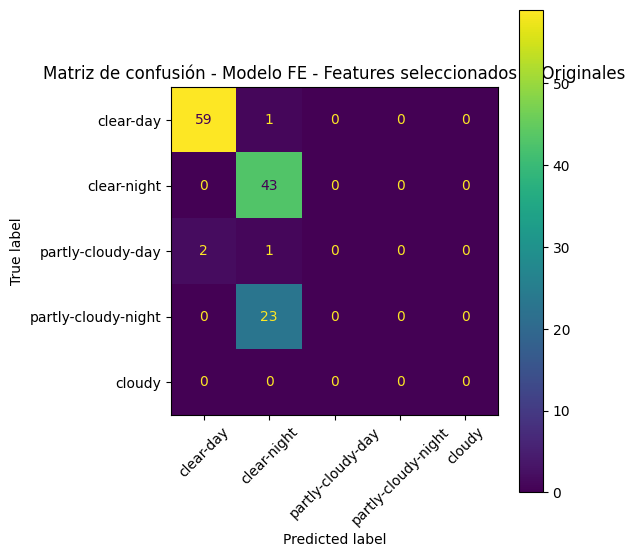

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[1, 2, 3, 4, 5]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'clear-day',
        'clear-night',
        'partly-cloudy-day',
        'partly-cloudy-night',
        'cloudy'
    ]
)

disp.plot(ax=ax, xticks_rotation=45)

plt.title('Matriz de confusión - Modelo FE - Features seleccionados + Originales')
plt.tight_layout()
plt.show()

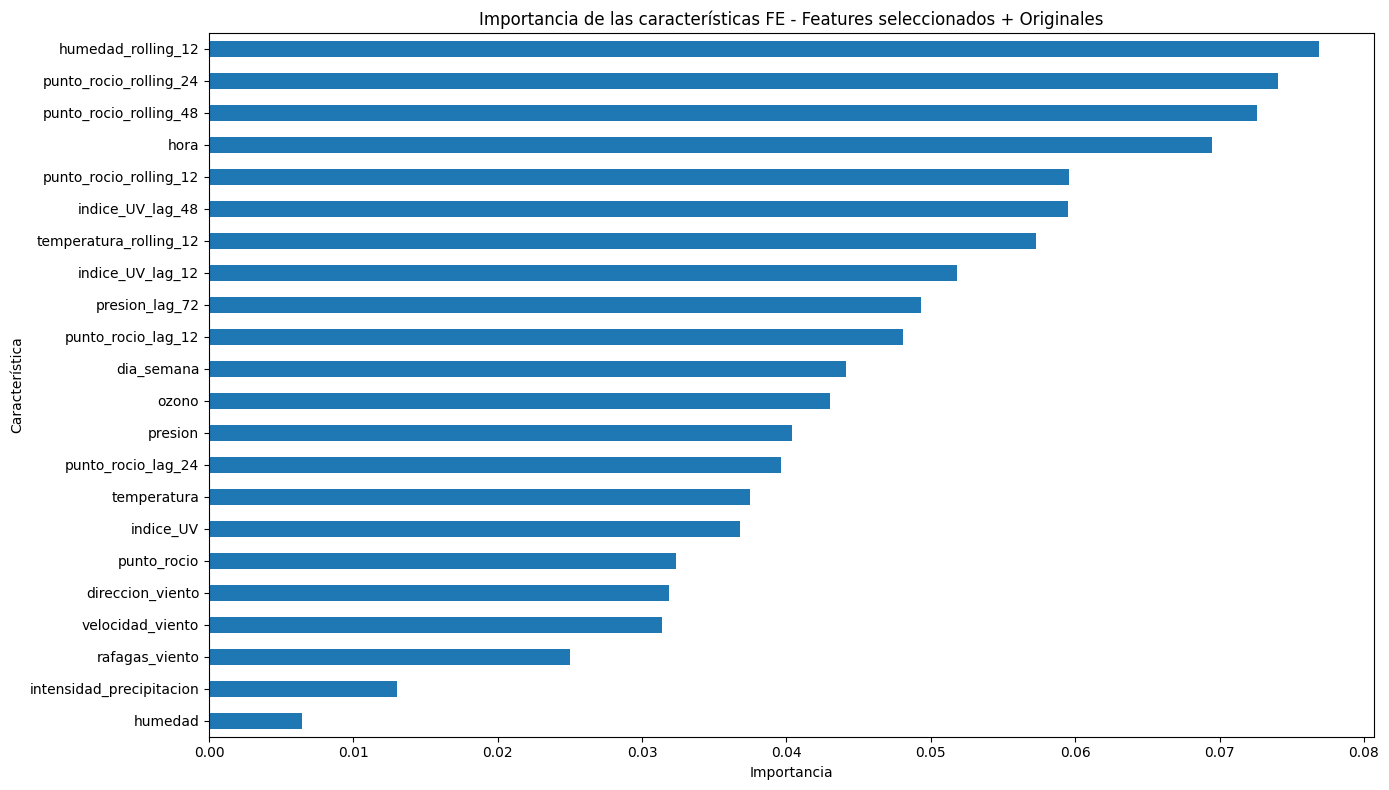

In [ ]:
# Importancia de las características

import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    modelo.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(14, 8))
importancias.plot(kind="barh")

plt.xlabel("Importancia")
plt.ylabel("Característica")
plt.title("Importancia de las características FE - Features seleccionados + Originales")

plt.tight_layout()
plt.show()

### 🧠 Analiza

Compara esta gráfica con las obtenidas en los experimentos anteriores.

- ¿Las características que anteriormente presentaban mayor importancia mantienen su posición al combinar los *features* seleccionados?

- Observa particularmente el comportamiento del **índice UV**, la **humedad** y el **punto de rocío**. ¿Qué cambios encuentras?

- ¿Qué puedes concluir acerca de la importancia de una característica cuando cambia el conjunto de *features* utilizado para entrenar el modelo?